In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q torch torchvision opencv-python-headless tqdm piq torchmetrics[image] pytorch-msssim scipy
# opencv-contrib needed for face detection (used before SFace)
!pip install -q opencv-contrib-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 11.5 MB/s eta 0:00:00


In [3]:
import os, sys, glob, json, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import piq
from pytorch_msssim import ms_ssim
from scipy.stats import entropy as scipy_entropy
from torchvision.models import inception_v3, Inception_V3_Weights

PROJECT_ROOT   = '/content/drive/MyDrive/Sketch2Face'
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'output_pix2pix_adaface', 'checkpoints')
TEST_DIR       = os.path.join(PROJECT_ROOT, 'dataset', 'split', 'test')
TRAIN_DIR      = os.path.join(PROJECT_ROOT, 'dataset', 'split', 'train')
RESULTS_DIR    = os.path.join(PROJECT_ROOT, 'results')

# Stage 1 output folders for Stage 2
STAGE1_TEST_OUT  = os.path.join(PROJECT_ROOT, 'stage1_outputs', 'test')
STAGE1_TRAIN_OUT = os.path.join(PROJECT_ROOT, 'stage1_outputs', 'train')

# SFace model — downloaded once and cached to Drive
SFACE_MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'face_recognition_sface_2021dec.onnx')

os.makedirs(RESULTS_DIR,      exist_ok=True)
os.makedirs(STAGE1_TEST_OUT,  exist_ok=True)
os.makedirs(STAGE1_TRAIN_OUT, exist_ok=True)
os.makedirs(os.path.dirname(SFACE_MODEL_PATH), exist_ok=True)
sys.path.insert(0, PROJECT_ROOT)

from dataset import CUHKDataset
from pix2pix import UNetGenerator

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device              : {DEVICE}')
print(f'Checkpoint dir      : {CHECKPOINT_DIR}')
print(f'SFace model path    : {SFACE_MODEL_PATH}')

Device              : cuda
Checkpoint dir      : /content/drive/MyDrive/Sketch2Face/output_pix2pix_adaface/checkpoints
SFace model path    : /content/drive/MyDrive/Sketch2Face/models/face_recognition_sface_2021dec.onnx


In [4]:
test_dataset  = CUHKDataset(TEST_DIR,  augment=False)
train_dataset = CUHKDataset(TRAIN_DIR, augment=False)

test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=2, pin_memory=DEVICE=='cuda')
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=DEVICE=='cuda')

print(f'Test  pairs : {len(test_dataset)}')
print(f'Train pairs : {len(train_dataset)}')

CUHKDataset | test | 38 pairs | augment=False
CUHKDataset | train | 150 pairs | augment=False
Test  pairs : 38
Train pairs : 150


In [5]:
# ── Download SFace model from OpenCV model zoo ───────────────────────────────
# Only downloads if not already cached in Drive

SFACE_URL = (
    'https://github.com/opencv/opencv_zoo/raw/main/models/'
    'face_recognition_sface/face_recognition_sface_2021dec.onnx'
)

if not os.path.exists(SFACE_MODEL_PATH):
    print('Downloading SFace model (~37MB)...')
    import urllib.request
    urllib.request.urlretrieve(SFACE_URL, SFACE_MODEL_PATH)
    print(f'Saved to: {SFACE_MODEL_PATH}')
else:
    print(f'SFace model already cached: {SFACE_MODEL_PATH}')

# Also need YuNet face detector to align faces before SFace
YUNET_PATH = os.path.join(PROJECT_ROOT, 'models', 'face_detection_yunet_2023mar.onnx')
YUNET_URL  = (
    'https://github.com/opencv/opencv_zoo/raw/main/models/'
    'face_detection_yunet/face_detection_yunet_2023mar.onnx'
)

if not os.path.exists(YUNET_PATH):
    print('Downloading YuNet face detector (~230KB)...')
    urllib.request.urlretrieve(YUNET_URL, YUNET_PATH)
    print(f'Saved to: {YUNET_PATH}')
else:
    print(f'YuNet model already cached: {YUNET_PATH}')

print('Models ready.')

Saved to: /content/drive/MyDrive/Sketch2Face/models/face_recognition_sface_2021dec.onnx
Saved to: /content/drive/MyDrive/Sketch2Face/models/face_detection_yunet_2023mar.onnx
Models ready.


In [6]:
# ── SFace feature extraction ──────────────────────────────────────────────────
# Exactly matches the paper: SFace features + cosine similarity

def get_sface_feature(img_bgr, sface_recognizer, yunet_detector, target_size=112):
    """
    Extract 128-d SFace feature vector from a BGR image.

    Pipeline:
        1. Run YuNet face detector to get face bbox + landmarks
        2. Align face using SFace built-in alignment
        3. Extract 128-d feature vector

    If no face detected, falls back to centre crop + resize.

    img_bgr      : uint8 BGR numpy array (H, W, 3)
    Returns      : (128,) float32 numpy feature vector, normalized to unit length
    """
    h, w = img_bgr.shape[:2]
    yunet_detector.setInputSize((w, h))
    _, faces = yunet_detector.detect(img_bgr)

    if faces is not None and len(faces) > 0:
        # Use the highest-confidence detection
        face = faces[0]
        aligned = sface_recognizer.alignCrop(img_bgr, face)
    else:
        # Fallback: centre crop to square, resize to 112x112
        side = min(h, w)
        y0   = (h - side) // 2
        x0   = (w - side) // 2
        crop = img_bgr[y0:y0+side, x0:x0+side]
        aligned = cv2.resize(crop, (target_size, target_size))

    feat = sface_recognizer.feature(aligned)   # (1, 128)
    feat = feat.flatten().astype(np.float32)
    norm = np.linalg.norm(feat)
    if norm > 1e-8:
        feat = feat / norm
    return feat


def cosine_similarity(a, b):
    """Cosine similarity between two unit-norm vectors. Range [-1, 1]."""
    return float(np.dot(a, b))


def extract_all_sface_features(img_tensors, sface_recognizer, yunet_detector):
    """
    Extract SFace features for a batch of images.
    img_tensors : (N, 3, H, W) float32 in [0, 1]
    Returns     : (N, 128) float32 numpy array
    """
    imgs_np = (img_tensors.permute(0, 2, 3, 1).cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
    features = []
    for img_rgb in imgs_np:
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        feat    = get_sface_feature(img_bgr, sface_recognizer, yunet_detector)
        features.append(feat)
    return np.stack(features, axis=0)   # (N, 128)


def compute_face_recognition_metrics(fake_features, real_features):
    """
    Compute Rank-1, VR@FAR0.1%, VR@FAR1% exactly as in the base paper.

    fake_features : (N, 128) — SFace features of generated images, in order
    real_features : (N, 128) — SFace features of real photos,     in order

    Index i in fake corresponds to index i in real (matched pairs).

    ── Rank-1 ──────────────────────────────────────────────────────────────
    For each generated image i (probe), compute cosine similarity against
    ALL real images (gallery). Rank-1 = correct real photo (index i) is
    ranked #1 (highest similarity) among all gallery images.

    ── VR @ FAR ────────────────────────────────────────────────────────────
    Genuine scores  : similarity(fake_i, real_i)  for all i   → N scores
    Impostor scores : similarity(fake_i, real_j)  for i ≠ j   → N*(N-1) scores

    FAR threshold at X% = the similarity value below which X% of impostor
    scores fall (i.e. the X-th percentile of impostor score distribution).

    VR = fraction of genuine scores that EXCEED that threshold.

    This is the standard NIST/biometric definition used in face recognition
    papers, matching exactly what the base paper reports.
    """
    N = fake_features.shape[0]

    # ── Build similarity matrix (N x N) ─────────────────────────────────
    # sim[i, j] = cosine similarity between fake_i and real_j
    sim_matrix = fake_features @ real_features.T   # (N, N), both unit-norm

    # ── Genuine scores: diagonal ─────────────────────────────────────────
    genuine_scores = np.diag(sim_matrix)           # (N,)

    # ── Impostor scores: all off-diagonal entries ────────────────────────
    mask           = ~np.eye(N, dtype=bool)
    impostor_scores = sim_matrix[mask]             # (N*(N-1),)

    # ── Rank-1 ──────────────────────────────────────────────────────────
    rank1_correct = 0
    for i in range(N):
        ranked = np.argsort(sim_matrix[i])[::-1]   # descending similarity
        if ranked[0] == i:
            rank1_correct += 1
    rank1 = round(rank1_correct / N * 100, 2)

    # ── VR @ FAR 0.1% ────────────────────────────────────────────────────
    # Threshold = 99.9th percentile of impostor scores
    # (only 0.1% of impostors score above this → FAR = 0.1%)
    thr_01  = np.percentile(impostor_scores, 99.9)
    vr_01   = round(float(np.mean(genuine_scores >= thr_01)) * 100, 2)

    # ── VR @ FAR 1% ──────────────────────────────────────────────────────
    thr_1   = np.percentile(impostor_scores, 99.0)
    vr_1    = round(float(np.mean(genuine_scores >= thr_1))  * 100, 2)

    return {
        'Rank-1'    : rank1,
        'VR@FAR0.1%': vr_01,
        'VR@FAR1%'  : vr_1,
        # Extra diagnostics — helpful to log
        '_genuine_mean'  : round(float(genuine_scores.mean()),  4),
        '_impostor_mean' : round(float(impostor_scores.mean()), 4),
        '_thr_01'        : round(float(thr_01), 4),
        '_thr_1'         : round(float(thr_1),  4),
    }


print('SFace recognition metric functions ready.')
print(f'  Test set N={len(test_dataset)} → {len(test_dataset)*(len(test_dataset)-1)} impostor pairs')

SFace recognition metric functions ready.
  Test set N=38 → 1406 impostor pairs


In [7]:
# ── SR-SIM ────────────────────────────────────────────────────────────────────

def spectral_residual_saliency(img_gray_np):
    img     = img_gray_np.astype(np.float32)
    f       = np.fft.fft2(img)
    log_mag = np.log(np.abs(f) + 1e-8)
    phase   = np.angle(f)
    avg_log  = cv2.blur(log_mag, (3, 3))
    residual = log_mag - avg_log
    sr  = np.exp(residual) * np.exp(1j * phase)
    sal = np.abs(np.fft.ifft2(sr)) ** 2
    sal = cv2.GaussianBlur(sal.astype(np.float32), (9, 9), 2.5)
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal

def compute_srsim(fake_tensor, real_tensor):
    scores  = []
    fake_np = fake_tensor.permute(0, 2, 3, 1).cpu().numpy()
    real_np = real_tensor.permute(0, 2, 3, 1).cpu().numpy()
    for i in range(fake_np.shape[0]):
        g_fake = cv2.cvtColor((fake_np[i]*255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)/255.0
        g_real = cv2.cvtColor((real_np[i]*255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)/255.0
        sal_f  = spectral_residual_saliency(g_fake)
        sal_r  = spectral_residual_saliency(g_real)
        weight = np.maximum(sal_f, sal_r)
        sim    = 1.0 - np.abs(g_fake - g_real)
        scores.append(float((sim * weight).sum() / (weight.sum() + 1e-8)))
    return float(np.mean(scores))


# ── IS ─────────────────────────────────────────────────────────────────────────

def compute_is(fake_imgs, device, batch_size=8):
    """Inception Score on generated images."""
    model = inception_v3(weights=Inception_V3_Weights.DEFAULT).eval().to(device)
    preds_list = []
    imgs_299 = F.interpolate(fake_imgs, size=(299,299), mode='bilinear', align_corners=False).to(device)
    with torch.no_grad():
        for i in range(0, imgs_299.size(0), batch_size):
            out = model(imgs_299[i:i+batch_size])
            logits = out if isinstance(out, torch.Tensor) else out.logits
            preds_list.append(F.softmax(logits, dim=1).cpu().numpy())
    preds = np.concatenate(preds_list, axis=0)
    p_y   = preds.mean(axis=0)
    kl    = [scipy_entropy(p, p_y) for p in preds]
    del model; torch.cuda.empty_cache()
    return round(float(np.exp(np.mean(kl))), 4)


# ── FID ─────────────────────────────────────────────────────────────────────────

def compute_fid(fake_imgs, real_imgs, device):
    from torchmetrics.image.fid import FrechetInceptionDistance
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    fid.update((real_imgs*255).clamp(0,255).to(torch.uint8).to(device), real=True)
    fid.update((fake_imgs*255).clamp(0,255).to(torch.uint8).to(device), real=False)
    return round(fid.compute().item(), 4)


print('All metric functions ready.')


All metric functions ready.


In [8]:
def generate_and_save(G, loader, dataset, save_dir, device, split_name):
    """Run generator, return tensors, and save images to Drive."""
    G.eval()
    all_fake, all_real = [], []
    idx = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Generating {split_name}'):
            sketches = batch['sketch'].to(device)
            photos   = batch['photo'].to(device)
            fake     = G(sketches)
            f01 = (fake   * 0.5 + 0.5).clamp(0, 1).cpu()
            r01 = (photos * 0.5 + 0.5).clamp(0, 1).cpu()
            all_fake.append(f01)
            all_real.append(r01)
            for j in range(f01.size(0)):
                _, photo_path = dataset.pairs[idx]
                fname    = os.path.basename(photo_path)
                img_np   = (f01[j].permute(1,2,0).numpy()*255).clip(0,255).astype(np.uint8)
                cv2.imwrite(os.path.join(save_dir, fname), cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))
                idx += 1
    print(f'  Saved {idx} images -> {save_dir}')
    return torch.cat(all_fake, dim=0), torch.cat(all_real, dim=0)


print('generate_and_save() ready.')


generate_and_save() ready.


In [9]:
def evaluate_checkpoint(ckpt_path, test_loader, test_dataset, device,
                        sface_recognizer, yunet_detector,
                        save_stage1=False,
                        stage1_test_dir=None,
                        train_loader=None, train_dataset=None,
                        stage1_train_dir=None):

    G    = UNetGenerator(in_ch=3, out_ch=3, ngf=64).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    G.load_state_dict(ckpt['G'])
    G.eval()

    # ── Generate images ──────────────────────────────────────────────────────
    if save_stage1 and stage1_test_dir:
        fake_imgs, real_imgs = generate_and_save(
            G, test_loader, test_dataset, stage1_test_dir, device, 'test')
    else:
        all_f, all_r = [], []
        with torch.no_grad():
            for batch in test_loader:
                fake = G(batch['sketch'].to(device))
                all_f.append((fake             * 0.5 + 0.5).clamp(0,1).cpu())
                all_r.append((batch['photo']   * 0.5 + 0.5).clamp(0,1).cpu())
        fake_imgs = torch.cat(all_f, dim=0)
        real_imgs = torch.cat(all_r, dim=0)

    if save_stage1 and train_loader and stage1_train_dir:
        generate_and_save(G, train_loader, train_dataset, stage1_train_dir, device, 'train')

    fake_d = fake_imgs.to(device)
    real_d = real_imgs.to(device)
    results = {}
    BS = 4

    # ── FID ──────────────────────────────────────────────────────────────────
    results['FID'] = compute_fid(fake_imgs, real_imgs, device)

    # ── SSIM ─────────────────────────────────────────────────────────────────
    s = [piq.ssim(fake_d[i:i+BS], real_d[i:i+BS], data_range=1.0).item()
         for i in range(0, len(fake_d), BS)]
    results['SSIM'] = round(float(np.mean(s)), 4)

    # ── MSSIM ────────────────────────────────────────────────────────────────
    s = [ms_ssim(fake_d[i:i+BS], real_d[i:i+BS], data_range=1.0, size_average=True).item()
         for i in range(0, len(fake_d), BS)]
    results['MSSIM'] = round(float(np.mean(s)), 4)

    # ── FSIM ─────────────────────────────────────────────────────────────────
    s = [piq.fsim(fake_d[i:i+BS], real_d[i:i+BS], data_range=1.0).item()
         for i in range(0, len(fake_d), BS)]
    results['FSIM'] = round(float(np.mean(s)), 4)

    # ── VIF ──────────────────────────────────────────────────────────────────
    s = [piq.vif_p(fake_d[i:i+BS], real_d[i:i+BS], data_range=1.0).item()
         for i in range(0, len(fake_d), BS)]
    results['VIF'] = round(float(np.mean(s)), 4)

    # ── SR-SIM ───────────────────────────────────────────────────────────────
    s = [compute_srsim(fake_imgs[i:i+BS], real_imgs[i:i+BS])
         for i in range(0, len(fake_imgs), BS)]
    results['SR-SIM'] = round(float(np.mean(s)), 4)

    # ── IS ───────────────────────────────────────────────────────────────────
    results['IS'] = compute_is(fake_imgs, device)

    # ── Face recognition: Rank-1, VR@FAR0.1%, VR@FAR1% ──────────────────────
    # Exactly matches base paper: SFace features + cosine similarity
    print('  Extracting SFace features...')
    fake_feats = extract_all_sface_features(fake_imgs, sface_recognizer, yunet_detector)
    real_feats = extract_all_sface_features(real_imgs, sface_recognizer, yunet_detector)

    recog = compute_face_recognition_metrics(fake_feats, real_feats)
    results['Rank-1']     = recog['Rank-1']
    results['VR@FAR0.1%'] = recog['VR@FAR0.1%']
    results['VR@FAR1%']   = recog['VR@FAR1%']

    # Log thresholds for transparency
    print(f'  Genuine  mean similarity : {recog["_genuine_mean"]}')
    print(f'  Impostor mean similarity : {recog["_impostor_mean"]}')
    print(f'  Threshold @ FAR 0.1%     : {recog["_thr_01"]}')
    print(f'  Threshold @ FAR 1%       : {recog["_thr_1"]}')

    del G, fake_imgs, real_imgs, fake_d, real_d
    torch.cuda.empty_cache()
    return results


print('evaluate_checkpoint() ready.')

evaluate_checkpoint() ready.


In [10]:
# ── Initialise SFace and YuNet — done once, reused across all checkpoints ────

sface_recognizer = cv2.FaceRecognizerSF.create(
    model    = SFACE_MODEL_PATH,
    config   = '',
    backend_id = cv2.dnn.DNN_BACKEND_OPENCV,
    target_id  = cv2.dnn.DNN_TARGET_CPU,
)

yunet_detector = cv2.FaceDetectorYN.create(
    model        = YUNET_PATH,
    config       = '',
    input_size   = (256, 256),
    score_threshold = 0.6,
    nms_threshold   = 0.3,
    top_k           = 1,
    backend_id   = cv2.dnn.DNN_BACKEND_OPENCV,
    target_id    = cv2.dnn.DNN_TARGET_CPU,
)

print('SFace recognizer initialised.')
print('YuNet detector  initialised.')
print()
print('Recognition metric definitions (matching base paper Table IV):')
print('  Rank-1       : correct real photo is top-1 match by cosine similarity')
print('  VR@FAR 0.1%  : verification rate when false accept rate = 0.1%')
print('  VR@FAR 1%    : verification rate when false accept rate = 1%')

SFace recognizer initialised.
YuNet detector  initialised.

Recognition metric definitions (matching base paper Table IV):
  Rank-1       : correct real photo is top-1 match by cosine similarity
  VR@FAR 0.1%  : verification rate when false accept rate = 0.1%
  VR@FAR 1%    : verification rate when false accept rate = 1%


In [11]:
ckpt_paths = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, 'ckpt_*.pth')))
final_path = os.path.join(CHECKPOINT_DIR, 'final.pth')
if os.path.exists(final_path) and final_path not in ckpt_paths:
    ckpt_paths.append(final_path)

print(f'Found {len(ckpt_paths)} checkpoints:')
for p in ckpt_paths:
    print(f'  {os.path.basename(p)}')

Found 10 checkpoints:
  ckpt_0020.pth
  ckpt_0040.pth
  ckpt_0060.pth
  ckpt_0080.pth
  ckpt_0100.pth
  ckpt_0120.pth
  ckpt_0140.pth
  ckpt_0160.pth
  ckpt_0180.pth
  ckpt_0200.pth


In [12]:
all_results = []

CSV_PATH  = os.path.join(RESULTS_DIR, 'all_epoch_metrics.csv')
JSON_PATH = os.path.join(RESULTS_DIR, 'all_epoch_metrics.json')

METRIC_ORDER = [
    'checkpoint',
    'FID', 'MSSIM', 'SSIM', 'FSIM', 'VIF', 'SR-SIM', 'IS',
    'Rank-1', 'VR@FAR0.1%', 'VR@FAR1%'
]

# ── Set this to your best checkpoint filename ─────────────────────────────────
BEST_CKPT = 'ckpt_0160.pth'   # <-- change if needed

for ckpt_path in tqdm(ckpt_paths, desc='Evaluating checkpoints'):
    ckpt_name = os.path.basename(ckpt_path).replace('.pth', '')
    is_best   = (os.path.basename(ckpt_path) == BEST_CKPT)
    print(f'\nEvaluating: {ckpt_name}  {"  <-- BEST" if is_best else ""}')

    try:
        scores = evaluate_checkpoint(
            ckpt_path        = ckpt_path,
            test_loader      = test_loader,
            test_dataset     = test_dataset,
            device           = DEVICE,
            sface_recognizer = sface_recognizer,
            yunet_detector   = yunet_detector,
            save_stage1          = is_best,
            stage1_test_dir      = STAGE1_TEST_OUT  if is_best else None,
            train_loader         = train_loader      if is_best else None,
            train_dataset        = train_dataset     if is_best else None,
            stage1_train_dir     = STAGE1_TRAIN_OUT  if is_best else None,
        )
        scores['checkpoint'] = ckpt_name
        all_results.append(scores)

        print(f'  FID         : {scores["FID"]}      (lower is better)')
        print(f'  MSSIM       : {scores["MSSIM"]}    (higher is better)')
        print(f'  SSIM        : {scores["SSIM"]}     (higher is better)')
        print(f'  FSIM        : {scores["FSIM"]}     (higher is better)')
        print(f'  VIF         : {scores["VIF"]}      (higher is better)')
        print(f'  SR-SIM      : {scores["SR-SIM"]}   (higher is better)')
        print(f'  IS          : {scores["IS"]}       (higher is better)')
        print(f'  Rank-1      : {scores["Rank-1"]}%  (higher is better)')
        print(f'  VR@FAR0.1%  : {scores["VR@FAR0.1%"]}%  (higher is better)')
        print(f'  VR@FAR1%    : {scores["VR@FAR1%"]}%  (higher is better)')

        if is_best:
            print(f'  Stage1 outputs saved:')
            print(f'    Test  -> {STAGE1_TEST_OUT}')
            print(f'    Train -> {STAGE1_TRAIN_OUT}')

        # Save incrementally — safe against Colab disconnects
        available = [c for c in METRIC_ORDER if c in pd.DataFrame(all_results).columns]
        pd.DataFrame(all_results)[available].to_csv(CSV_PATH, index=False)
        with open(JSON_PATH, 'w') as jf:
            json.dump(all_results, jf, indent=2)

    except Exception as e:
        print(f'  ERROR: {e}')
        import traceback; traceback.print_exc()

print('\nAll checkpoints evaluated.')
print(f'Results -> {CSV_PATH}')

Evaluating checkpoints:   0%|          | 0/10 [00:00<?, ?it/s]


Evaluating: ckpt_0020  


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth

  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 29%|██▉       | 26.6M/91.2M [00:00<00:00, 279MB/s]
100%|██████████| 91.2M/91.2M [00:00<00:00, 390MB/s]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth



  0%|          | 0.00/104M [00:00<?, ?B/s]
  9%|▉         | 9.12M/104M [00:00<00:01, 95.6MB/s]
 20%|██        | 21.1M/104M [00:00<00:00, 113MB/s] 
 32%|███▏      | 33.5M/104M [00:00<00:00, 120MB/s]
 45%|████▍     | 46.6M/104M [00:00<00:00, 127MB/s]
 58%|█████▊    | 59.9M/104M [00:00<00:00, 131MB/s]
 70%|███████   | 72.9M/104M [00:00<00:00, 133MB/s]
 83%|████████▎ | 85.8M/104M [00:00<00:00, 133MB/s]
100%|██████████| 104M/104M [00:00<00:00, 123MB/s] 


...

  Genuine  mean similarity : 0.4993
  Impostor mean similarity : 0.1756
  Threshold @ FAR 0.1%     : 0.4471
  Threshold @ FAR 1%       : 0.4118
  FID         : 74.0887      (lower is better)
  MSSIM       : 0.8378    (higher is better)
  SSIM        : 0.7199     (higher is better)
  FSIM        : 0.8175     (higher is better)
  VIF         : 0.236      (higher is better)
  SR-SIM      : 0.8707   (higher is better)
  IS          : 1.3632       (higher is better)
  Rank-1      : 92.11%  (higher is better)
  VR@FAR0.1%  : 65.79%  (higher is better)
  VR@FAR1%    : 86.84%  (higher is better)
  Stage1 outputs saved:
    Test  -> /content/drive/MyDrive/Sketch2Face/stage1_outputs/test
    Train -> /content/drive/MyDrive/Sketch2Face/stage1_outputs/train

Evaluating: ckpt_0180  
  Extracting SFace features...


Evaluating checkpoints:  90%|█████████ | 9/10 [05:58<00:43, 43.47s/it]

  Genuine  mean similarity : 0.5
  Impostor mean similarity : 0.1797
  Threshold @ FAR 0.1%     : 0.4715
  Threshold @ FAR 1%       : 0.4146
  FID         : 77.8912      (lower is better)
  MSSIM       : 0.8415    (higher is better)
  SSIM        : 0.7252     (higher is better)
  FSIM        : 0.8174     (higher is better)
  VIF         : 0.2382      (higher is better)
  SR-SIM      : 0.8689   (higher is better)
  IS          : 1.3839       (higher is better)
  Rank-1      : 92.11%  (higher is better)
  VR@FAR0.1%  : 63.16%  (higher is better)
  VR@FAR1%    : 86.84%  (higher is better)

Evaluating: ckpt_0200  
  Extracting SFace features...


Evaluating checkpoints: 100%|██████████| 10/10 [06:26<00:00, 38.64s/it]

  Genuine  mean similarity : 0.5009
  Impostor mean similarity : 0.1788
  Threshold @ FAR 0.1%     : 0.4593
  Threshold @ FAR 1%       : 0.4117
  FID         : 75.5673      (lower is better)
  MSSIM       : 0.8413    (higher is better)
  SSIM        : 0.7243     (higher is better)
  FSIM        : 0.8173     (higher is better)
  VIF         : 0.2385      (higher is better)
  SR-SIM      : 0.8683   (higher is better)
  IS          : 1.3647       (higher is better)
  Rank-1      : 86.84%  (higher is better)
  VR@FAR0.1%  : 71.05%  (higher is better)
  VR@FAR1%    : 84.21%  (higher is better)

All checkpoints evaluated.
Results -> /content/drive/MyDrive/Sketch2Face/results/all_epoch_metrics.csv


Checkpoint            FID      MSSIM       SSIM       FSIM        VIF     SR-SIM         IS     Rank-1 VR@FAR0.1%   VR@FAR1%
--------------------------------------------------------------------------------------------------------------
ckpt_0020        102.2045     0.8322     0.7009     0.8145     0.2312     0.8699     1.2404     76.32%     55.26%     76.32%
ckpt_0040         98.2831     0.8380     0.7161     0.8160     0.2380     0.8717     1.2510     84.21%     55.26%     84.21%
ckpt_0060        105.1915     0.8351     0.7146     0.8165     0.2377     0.8705     1.2812     86.84%     65.79%     86.84%
ckpt_0080         87.2844     0.8387     0.7170     0.8158     0.2376     0.8706     1.2729     86.84%     60.53%     84.21%
ckpt_0100         84.5343     0.8296     0.7046     0.8139     0.2298     0.8721     1.2903     81.58%     57.89%     81.58%
ckpt_0120         78.8318     0.8389     0.7191     0.8172     0.2366     0.8693     1.2629     84.21%     57.89%     89.47%
ckpt_0140     

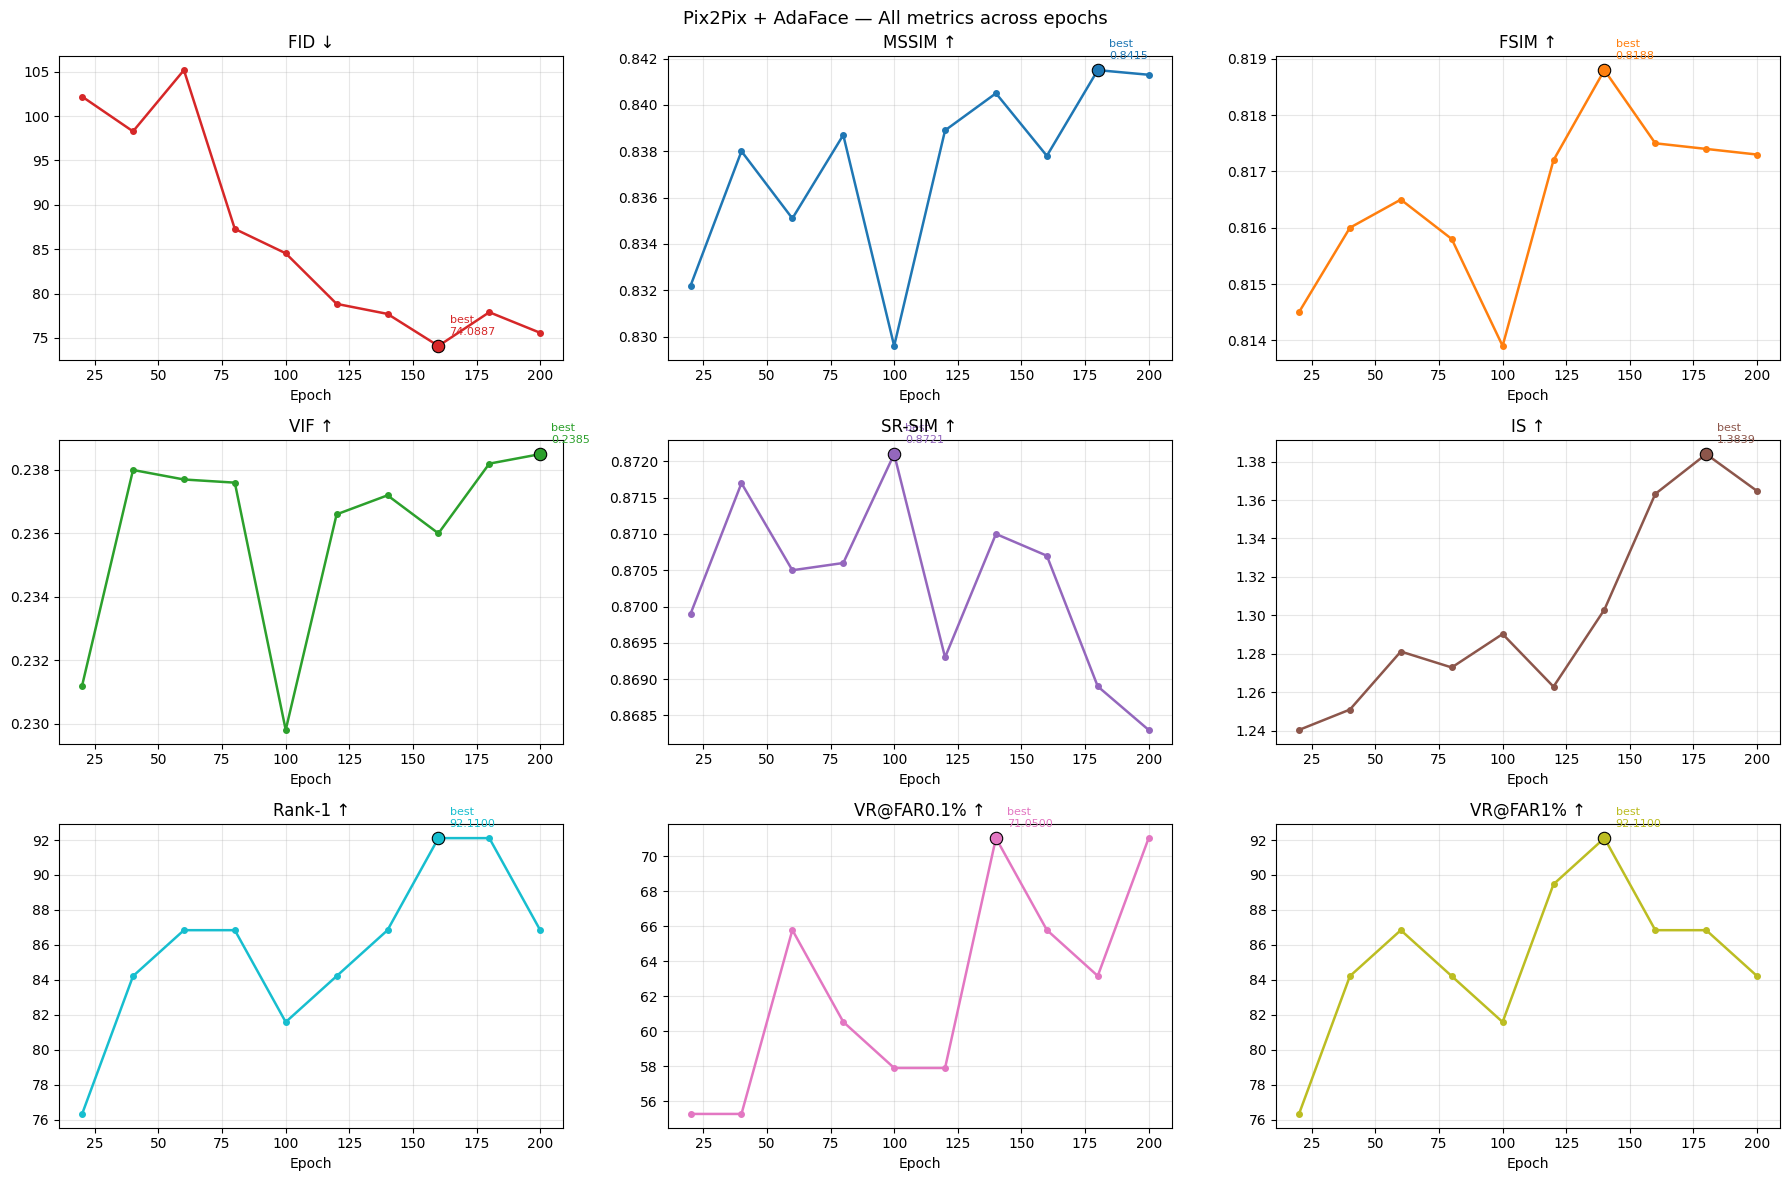

Chart saved: /content/drive/MyDrive/Sketch2Face/results/metrics_across_epochs.png


In [13]:
df = pd.DataFrame(all_results)
df['epoch'] = df['checkpoint'].apply(
    lambda x: int(x.replace('ckpt_','').lstrip('0') or '0')
    if x.replace('ckpt_','').lstrip('0').isdigit()
    else (9999 if 'final' in x else 0)
)
df = df.sort_values('epoch').reset_index(drop=True)

SHOW = ['checkpoint','FID','MSSIM','SSIM','FSIM','VIF','SR-SIM','IS','Rank-1','VR@FAR0.1%','VR@FAR1%']
SHOW = [c for c in SHOW if c in df.columns]

# ── Print table ───────────────────────────────────────────────────────────────
print('=' * 110)
print(f"{'Checkpoint':<14}" + ''.join(f'{c:>11}' for c in SHOW[1:]))
print('-' * 110)
for _, row in df.iterrows():
    line = f"{row['checkpoint']:<14}"
    for c in SHOW[1:]:
        v = row[c]
        if c in ('Rank-1','VR@FAR0.1%','VR@FAR1%'):
            line += f"{v:>10.2f}%"
        else:
            line += f"{v:>11.4f}"
    print(line)
print('=' * 110)

# ── Best per metric ───────────────────────────────────────────────────────────
print('\nBest epoch per metric:')
lower = {'FID'}
for c in SHOW[1:]:
    if c in df.columns:
        idx = df[c].idxmin() if c in lower else df[c].idxmax()
        suffix = '%' if c in ('Rank-1','VR@FAR0.1%','VR@FAR1%') else ''
        print(f'  {c:<12} : {df.loc[idx,"checkpoint"]}  ->  {df.loc[idx,c]:.4f}{suffix}')

# ── Base paper targets (CUHK) ─────────────────────────────────────────────────
print('\nBase paper targets (CUHK):')
targets = {
    'SR-SIM':'0.8860','MSSIM':'0.8503','FID':'64.54',
    'FSIM':'0.8206','VIF':'0.2251','IS':'1.46',
    'Rank-1':'78.95%','VR@FAR0.1%':'21.05%','VR@FAR1%':'36.84%'
}
for k,v in targets.items():
    print(f'  {k:<12} : {v}')

# ── Charts ────────────────────────────────────────────────────────────────────
metrics_cfg = [
    ('FID',       'FID ↓',          'tab:red',    True),
    ('MSSIM',     'MSSIM ↑',        'tab:blue',   False),
    ('FSIM',      'FSIM ↑',         'tab:orange', False),
    ('VIF',       'VIF ↑',          'tab:green',  False),
    ('SR-SIM',    'SR-SIM ↑',       'tab:purple', False),
    ('IS',        'IS ↑',           'tab:brown',  False),
    ('Rank-1',    'Rank-1 ↑',       'tab:cyan',   False),
    ('VR@FAR0.1%','VR@FAR0.1% ↑',  'tab:pink',   False),
    ('VR@FAR1%',  'VR@FAR1% ↑',    'tab:olive',  False),
]
metrics_cfg = [(m,l,c,lb) for m,l,c,lb in metrics_cfg if m in df.columns]
epochs = df['epoch'].tolist()

ncols = 3
nrows = (len(metrics_cfg) + 2) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()

for ax, (col, title, color, lb) in zip(axes, metrics_cfg):
    vals = df[col].tolist()
    ax.plot(epochs, vals, color=color, marker='o', markersize=4, linewidth=1.8)
    best_i = int(np.argmin(vals) if lb else np.argmax(vals))
    ax.scatter([epochs[best_i]], [vals[best_i]], color=color, s=80,
               zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(f'best\n{vals[best_i]:.4f}',
                xy=(epochs[best_i], vals[best_i]),
                xytext=(8,8), textcoords='offset points',
                fontsize=8, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

for ax in axes[len(metrics_cfg):]:
    ax.set_visible(False)

plt.suptitle('Pix2Pix + AdaFace — All metrics across epochs', fontsize=13)
plt.tight_layout()
chart_path = os.path.join(RESULTS_DIR, 'metrics_across_epochs.png')
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')
df.to_csv(os.path.join(RESULTS_DIR, 'all_epoch_metrics_final.csv'), index=False)

In [14]:
# ── Verify Stage 1 outputs ────────────────────────────────────────────────────
test_files  = glob.glob(os.path.join(STAGE1_TEST_OUT,  '*.png')) +               glob.glob(os.path.join(STAGE1_TEST_OUT,  '*.jpg'))
train_files = glob.glob(os.path.join(STAGE1_TRAIN_OUT, '*.png')) +               glob.glob(os.path.join(STAGE1_TRAIN_OUT, '*.jpg'))

print(f'Stage1 test  outputs : {len(test_files)}  images in {STAGE1_TEST_OUT}')
print(f'Stage1 train outputs : {len(train_files)} images in {STAGE1_TRAIN_OUT}')

if len(test_files) == 0:
    print('WARNING: No outputs found. Check BEST_CKPT name matches your checkpoint file.')
else:
    print('\nSample filenames:')
    for f in sorted(test_files)[:3]:
        print(f'  {os.path.basename(f)}')
    print('\nStage 1 outputs ready. Stage 2 input folder:')
    print(f'  {STAGE1_TEST_OUT}')

Stage1 test  outputs : 38  images in /content/drive/MyDrive/Sketch2Face/stage1_outputs/test
Stage1 train outputs : 150 images in /content/drive/MyDrive/Sketch2Face/stage1_outputs/train

Sample filenames:
  f-006-01.png
  f-011-01.png
  f-012-01.png

Stage 1 outputs ready. Stage 2 input folder:
  /content/drive/MyDrive/Sketch2Face/stage1_outputs/test


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torch torchvision opencv-python-headless tqdm piq torchmetrics[image] pytorch-msssim scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.6 MB/s eta 0:00:00


In [ ]:
import os
import sys
import glob
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import piq
from pytorch_msssim import ms_ssim
from scipy.stats import entropy as scipy_entropy
from torchvision.models import inception_v3

PROJECT_ROOT = '/content/drive/MyDrive/Sketch2Face'

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'output_pix2pix_adaface', 'checkpoints')
TEST_DIR       = os.path.join(PROJECT_ROOT, 'dataset', 'split', 'test')
RESULTS_DIR    = os.path.join(PROJECT_ROOT, 'results')

os.makedirs(RESULTS_DIR, exist_ok=True)
sys.path.insert(0, PROJECT_ROOT)

from dataset import CUHKDataset
from pix2pix import UNetGenerator

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device         : {DEVICE}')
print(f'Checkpoint dir : {CHECKPOINT_DIR}')
print(f'Test dir       : {TEST_DIR}')

Device         : cpu
Checkpoint dir : /content/drive/MyDrive/Sketch2Face/output_pix2pix_adaface/checkpoints
Test dir       : /content/drive/MyDrive/Sketch2Face/dataset/split/test


In [ ]:
test_dataset = CUHKDataset(TEST_DIR, augment=False)
test_loader  = DataLoader(
    test_dataset,
    batch_size  = 4,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = DEVICE == 'cuda',
)
print(f'Test pairs   : {len(test_dataset)}')
print(f'Test batches : {len(test_loader)}')

CUHKDataset | test | 38 pairs | augment=False
Test pairs   : 38
Test batches : 10


In [ ]:
def spectral_residual_saliency(img_gray_np):
    """
    Compute spectral residual saliency map.
    img_gray_np : (H, W) float32 in [0, 1]
    Returns     : (H, W) float32 saliency map in [0, 1]
    """
    img = img_gray_np.astype(np.float32)

    # FFT
    f       = np.fft.fft2(img)
    log_mag = np.log(np.abs(f) + 1e-8)
    phase   = np.angle(f)

    # Spectral residual = log magnitude - smoothed log magnitude
    avg_log  = cv2.blur(log_mag, (3, 3))
    residual = log_mag - avg_log

    # Reconstruct saliency
    sr  = np.exp(residual) * np.exp(1j * phase)
    sal = np.abs(np.fft.ifft2(sr)) ** 2
    sal = cv2.GaussianBlur(sal.astype(np.float32), (9, 9), 2.5)

    # Normalise to [0, 1]
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal


def compute_srsim(fake_tensor, real_tensor):
    """
    SR-SIM between two batches.
    fake_tensor, real_tensor : (B, 3, H, W) float32 in [0, 1]
    Returns mean SR-SIM score as float.
    """
    scores  = []
    fake_np = fake_tensor.permute(0, 2, 3, 1).cpu().numpy()  # (B, H, W, 3)
    real_np = real_tensor.permute(0, 2, 3, 1).cpu().numpy()

    for i in range(fake_np.shape[0]):
        # Convert to grayscale
        g_fake = cv2.cvtColor(
            (fake_np[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY
        ).astype(np.float32) / 255.0
        g_real = cv2.cvtColor(
            (real_np[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY
        ).astype(np.float32) / 255.0

        # Saliency maps
        sal_fake = spectral_residual_saliency(g_fake)
        sal_real = spectral_residual_saliency(g_real)

        # Weight = element-wise max of both saliency maps
        weight = np.maximum(sal_fake, sal_real)

        # Local similarity
        sim   = 1.0 - np.abs(g_fake - g_real)

        # Weighted mean similarity
        score = (sim * weight).sum() / (weight.sum() + 1e-8)
        scores.append(float(score))

    return float(np.mean(scores))


print('SR-SIM implementation ready.')

SR-SIM implementation ready.


In [ ]:
def generate_images(G, test_loader, device):
    G.eval()
    all_fake, all_real = [], []
    with torch.no_grad():
        for batch in test_loader:
            sketches = batch["sketch"].to(device)
            photos   = batch["photo"].to(device)
            fake     = G(sketches)
            all_fake.append((fake   * 0.5 + 0.5).clamp(0, 1).cpu())
            all_real.append((photos * 0.5 + 0.5).clamp(0, 1).cpu())
    return torch.cat(all_fake, dim=0), torch.cat(all_real, dim=0)


def compute_fid(fake_imgs, real_imgs, device):
    """
    FID using torchmetrics.
    fake_imgs, real_imgs : (N, 3, H, W) float32 in [0, 1]
    torchmetrics FID expects uint8 tensors in [0, 255].
    """
    from torchmetrics.image.fid import FrechetInceptionDistance
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)

    # Convert to uint8 [0, 255] — torchmetrics FID expects this
    fake_uint8 = (fake_imgs * 255).clamp(0, 255).to(torch.uint8).to(device)
    real_uint8 = (real_imgs * 255).clamp(0, 255).to(torch.uint8).to(device)

    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return round(fid.compute().item(), 4)


def evaluate_checkpoint(ckpt_path, test_loader, device):
    G    = UNetGenerator(in_ch=3, out_ch=3, ngf=64).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    G.load_state_dict(ckpt["G"])
    G.eval()

    fake_imgs, real_imgs = generate_images(G, test_loader, device)
    fake_d    = fake_imgs.to(device)
    real_d    = real_imgs.to(device)
    results   = {}
    batch_size = 4

    # ── FID ─────────────────────────────────────────────────────
    results["FID"] = compute_fid(fake_imgs, real_imgs, device)

    # ── SSIM ────────────────────────────────────────────────────
    ssim_scores = []
    for i in range(0, len(fake_d), batch_size):
        f = fake_d[i:i + batch_size]
        r = real_d[i:i + batch_size]
        ssim_scores.append(piq.ssim(f, r, data_range=1.0).item())
    results["SSIM"] = round(float(np.mean(ssim_scores)), 4)

    # ── FSIM ────────────────────────────────────────────────────
    fsim_scores = []
    for i in range(0, len(fake_d), batch_size):
        f = fake_d[i:i + batch_size]
        r = real_d[i:i + batch_size]
        fsim_scores.append(piq.fsim(f, r, data_range=1.0).item())
    results["FSIM"] = round(float(np.mean(fsim_scores)), 4)

    # ── VIF ─────────────────────────────────────────────────────
    vif_scores = []
    for i in range(0, len(fake_d), batch_size):
        f = fake_d[i:i + batch_size]
        r = real_d[i:i + batch_size]
        vif_scores.append(piq.vif_p(f, r, data_range=1.0).item())
    results["VIF"] = round(float(np.mean(vif_scores)), 4)

    # ── SR-SIM ──────────────────────────────────────────────────
    srsim_scores = []
    for i in range(0, len(fake_imgs), batch_size):
        f = fake_imgs[i:i + batch_size]
        r = real_imgs[i:i + batch_size]
        srsim_scores.append(compute_srsim(f, r))
    results["SR-SIM"] = round(float(np.mean(srsim_scores)), 4)

    # ── MSSIM ───────────────────────────────────────────────────
    mssim_scores = []
    for i in range(0, len(fake_d), batch_size):
        f01 = fake_d[i:i + batch_size]
        r01 = real_d[i:i + batch_size]
        mssim_scores.append(
            ms_ssim(f01, r01, data_range=1.0, size_average=True).item()
        )
    results["MSSIM"] = round(float(np.mean(mssim_scores)), 4)

    # ── IS (Inception Score) ─────────────────────────────────────
    # IS = exp( E_x[ KL( p(y|x) || p(y) ) ] )
    # Uses InceptionV3 softmax predictions on generated images.
    inc_model = inception_v3(pretrained=True, transform_input=False).to(device)
    inc_model.eval()
    preds_list = []
    inc_bs = 8
    # Resize to 299x299 as required by InceptionV3
    fake_299 = F.interpolate(fake_d, size=(299, 299),
                             mode='bilinear', align_corners=False)
    with torch.no_grad():
        for i in range(0, fake_299.size(0), inc_bs):
            out = inc_model(fake_299[i:i + inc_bs])
            preds_list.append(F.softmax(out, dim=1).cpu().numpy())
    preds   = np.concatenate(preds_list, axis=0)   # (N, 1000)
    p_y     = preds.mean(axis=0)                   # marginal p(y)
    kl_divs = [scipy_entropy(p, p_y) for p in preds]
    results["IS"] = round(float(np.exp(np.mean(kl_divs))), 4)
    del inc_model

    del G, fake_imgs, real_imgs, fake_d, real_d
    torch.cuda.empty_cache()

    return results


print("Evaluation functions ready.")

Evaluation functions ready.


In [ ]:
# Find all checkpoints sorted by epoch
ckpt_paths = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, 'ckpt_*.pth')))

# Include final.pth if it exists
final_path = os.path.join(CHECKPOINT_DIR, 'final.pth')
if os.path.exists(final_path) and final_path not in ckpt_paths:
    ckpt_paths.append(final_path)

if len(ckpt_paths) == 0:
    print('No checkpoints found. Run 03_train_coarse.ipynb first.')
else:
    print(f'Found {len(ckpt_paths)} checkpoint(s):')
    for p in ckpt_paths:
        print(f'  {os.path.basename(p)}')

Found 10 checkpoint(s):
  ckpt_0020.pth
  ckpt_0040.pth
  ckpt_0060.pth
  ckpt_0080.pth
  ckpt_0100.pth
  ckpt_0120.pth
  ckpt_0140.pth
  ckpt_0160.pth
  ckpt_0180.pth
  ckpt_0200.pth


In [ ]:
all_results = []

# Output paths
CSV_PATH  = os.path.join(RESULTS_DIR, 'all_epoch_metrics.csv')
JSON_PATH = os.path.join(RESULTS_DIR, 'all_epoch_metrics.json')

METRIC_ORDER = ['checkpoint', 'FID', 'MSSIM', 'FSIM', 'VIF', 'SR-SIM', 'IS']

for ckpt_path in tqdm(ckpt_paths, desc='Evaluating checkpoints'):
    ckpt_name = os.path.basename(ckpt_path).replace('.pth', '')
    print(f'\nEvaluating: {ckpt_name}')

    try:
        scores = evaluate_checkpoint(ckpt_path, test_loader, DEVICE)
        scores['checkpoint'] = ckpt_name
        all_results.append(scores)

        print(f'  FID    : {scores["FID"]}      (lower is better)')
        print(f'  MSSIM  : {scores["MSSIM"]}    (higher is better)')
        print(f'  FSIM   : {scores["FSIM"]}     (higher is better)')
        print(f'  VIF    : {scores["VIF"]}      (higher is better)')
        print(f'  SR-SIM : {scores["SR-SIM"]}   (higher is better)')
        print(f'  IS     : {scores["IS"]}       (higher is better)')

        # ── Save incrementally after every checkpoint ─────────────────────
        # So results are not lost if Colab disconnects mid-run
        df_so_far = pd.DataFrame(all_results)[METRIC_ORDER]
        df_so_far.to_csv(CSV_PATH,  index=False)
        with open(JSON_PATH, 'w') as jf:
            json.dump(all_results, jf, indent=2)

    except Exception as e:
        print(f'  ERROR: {e}')

print('\nAll checkpoints evaluated.')
print(f'Results saved to:\n  {CSV_PATH}\n  {JSON_PATH}')

Evaluating checkpoints:   0%|          | 0/10 [00:00<?, ?it/s]


Evaluating: ckpt_0020


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth

  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 14%|█▍        | 12.9M/91.2M [00:00<00:00, 135MB/s]
 35%|███▌      | 32.2M/91.2M [00:00<00:00, 174MB/s]
 59%|█████▊    | 53.5M/91.2M [00:00<00:00, 196MB/s]
100%|██████████| 91.2M/91.2M [00:00<00:00, 187MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth



  0%|          | 0.00/104M [00:00<?, ?B/s]
  7%|▋         | 6.88M/104M [00:00<00:01, 71.6MB/s]
 20%|██        | 21.2M/104M [00:00<00:00, 117MB/s] 
 33%|███▎      | 34.6M/104M [00:00<00:00, 128MB/s]
 47%|████▋     | 48.9M/104M [00:00<00:00, 136MB/s]
 60%|█████▉    | 61.9M/104M [00:00<00:00, 134MB/s]
 74%|███████▎  | 76.6M/104M [00:00<00:00, 140MB/s]
100%|██████████| 104M/104M [00:00<00:00, 131MB/s] 
Evaluating checkpoints:  10%|█         | 1/10 [01:54<17:11, 114.67s/it]

...

  FID    : 74.0887      (lower is better)
  MSSIM  : 0.8378    (higher is better)
  FSIM   : 0.8175     (higher is better)
  VIF    : 0.236      (higher is better)
  SR-SIM : 0.8707   (higher is better)
  IS     : 1.4028       (higher is better)

Evaluating: ckpt_0180


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Evaluating checkpoints:  90%|█████████ | 9/10 [14:39<01:35, 95.13s/it]

  FID    : 77.8892      (lower is better)
  MSSIM  : 0.8415    (higher is better)
  FSIM   : 0.8174     (higher is better)
  VIF    : 0.2382      (higher is better)
  SR-SIM : 0.8689   (higher is better)
  IS     : 1.3953       (higher is better)

Evaluating: ckpt_0200


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Evaluating checkpoints: 100%|██████████| 10/10 [16:13<00:00, 97.33s/it]

  FID    : 75.5679      (lower is better)
  MSSIM  : 0.8413    (higher is better)
  FSIM   : 0.8173     (higher is better)
  VIF    : 0.2385      (higher is better)
  SR-SIM : 0.8683   (higher is better)
  IS     : 1.3876       (higher is better)

All checkpoints evaluated.
Results saved to:
  /content/drive/MyDrive/Sketch2Face/results/all_epoch_metrics.csv
  /content/drive/MyDrive/Sketch2Face/results/all_epoch_metrics.json


Checkpoint         FID   MSSIM    FSIM     VIF   SR-SIM     IS
-----------------------------------------------------------------
ckpt_0020      102.2059  0.8322  0.8145  0.2312   0.8699  1.262
ckpt_0040      98.2818  0.8380  0.8160  0.2380   0.8717  1.273
ckpt_0060      105.1937  0.8351  0.8165  0.2377   0.8705  1.333
ckpt_0080      87.2830  0.8387  0.8158  0.2376   0.8706  1.354
ckpt_0100      84.5346  0.8296  0.8139  0.2298   0.8721  1.319
ckpt_0120      78.8317  0.8389  0.8172  0.2366   0.8693  1.331
ckpt_0140      77.6992  0.8405  0.8188  0.2372   0.8710  1.383
ckpt_0160      74.0887  0.8378  0.8175  0.2360   0.8707  1.403
ckpt_0180      77.8892  0.8415  0.8174  0.2382   0.8689  1.395
ckpt_0200      75.5679  0.8413  0.8173  0.2385   0.8683  1.388

Best epoch per metric:
  FID    (min) : ckpt_0160  -> 74.0887
  MSSIM  (max) : ckpt_0180  -> 0.8415
  FSIM   (max) : ckpt_0140  -> 0.8188
  VIF    (max) : ckpt_0200  -> 0.2385
  SR-SIM (max) : ckpt_0100  -> 0.8721
  IS     (max) : ckpt_01

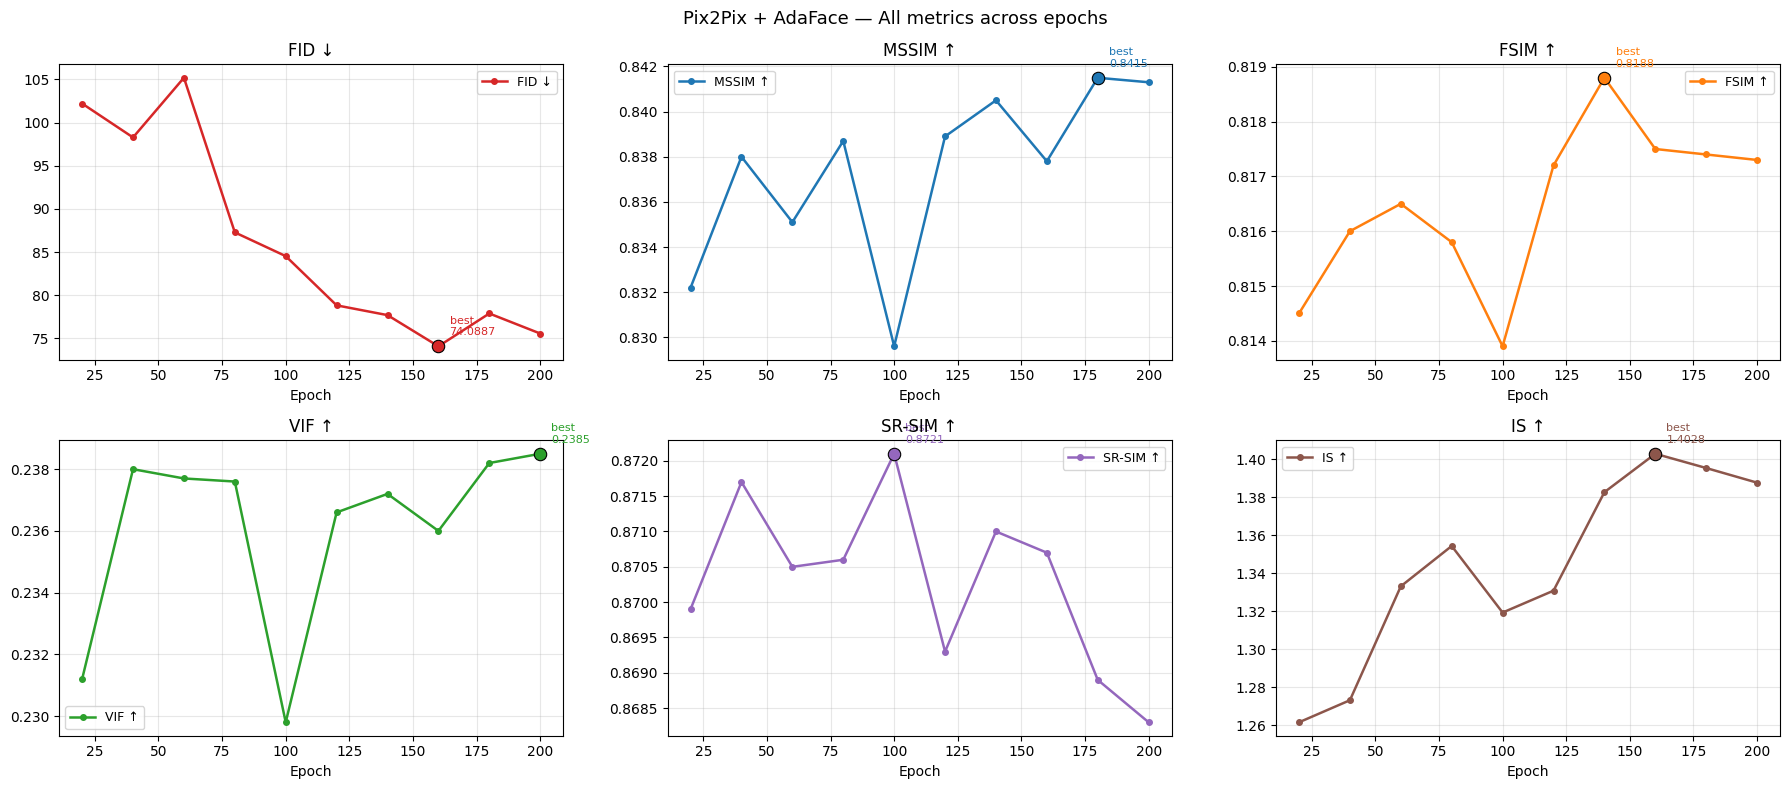

Chart saved: /content/drive/MyDrive/Sketch2Face/results/metrics_across_epochs.png
Final CSV  : /content/drive/MyDrive/Sketch2Face/results/all_epoch_metrics.csv


In [ ]:
# ── Summary table ────────────────────────────────────────────────────────────
df = pd.DataFrame(all_results)[METRIC_ORDER]

# Parse epoch number for x-axis
def epoch_num(ckpt_name):
    try:    return int(ckpt_name.replace('ckpt_', '').replace('final', '9999'))
    except: return 0

df['epoch'] = df['checkpoint'].apply(epoch_num)
df = df.sort_values('epoch').reset_index(drop=True)

print("=" * 65)
print(f"{'Checkpoint':<14} {'FID':>7} {'MSSIM':>7} {'FSIM':>7} {'VIF':>7} {'SR-SIM':>8} {'IS':>6}")
print("-" * 65)
for _, row in df.iterrows():
    print(f"{row['checkpoint']:<14} {row['FID']:>7.4f} {row['MSSIM']:>7.4f} "
          f"{row['FSIM']:>7.4f} {row['VIF']:>7.4f} {row['SR-SIM']:>8.4f} {row['IS']:>6.3f}")
print("=" * 65)

# Best epoch per metric
print("\nBest epoch per metric:")
print(f"  FID    (min) : {df.loc[df['FID'].idxmin(),    'checkpoint']}  -> {df['FID'].min():.4f}")
print(f"  MSSIM  (max) : {df.loc[df['MSSIM'].idxmax(),  'checkpoint']}  -> {df['MSSIM'].max():.4f}")
print(f"  FSIM   (max) : {df.loc[df['FSIM'].idxmax(),   'checkpoint']}  -> {df['FSIM'].max():.4f}")
print(f"  VIF    (max) : {df.loc[df['VIF'].idxmax(),    'checkpoint']}  -> {df['VIF'].max():.4f}")
print(f"  SR-SIM (max) : {df.loc[df['SR-SIM'].idxmax(), 'checkpoint']}  -> {df['SR-SIM'].max():.4f}")
print(f"  IS     (max) : {df.loc[df['IS'].idxmax(),     'checkpoint']}  -> {df['IS'].max():.4f}")

# ── Metric charts across epochs ───────────────────────────────────────────────
epochs = df['epoch'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

metrics_cfg = [
    ('FID',    'FID ↓',    'tab:red',    True),
    ('MSSIM',  'MSSIM ↑',  'tab:blue',   False),
    ('FSIM',   'FSIM ↑',   'tab:orange', False),
    ('VIF',    'VIF ↑',    'tab:green',  False),
    ('SR-SIM', 'SR-SIM ↑', 'tab:purple', False),
    ('IS',     'IS ↑',     'tab:brown',  False),
]

for ax, (col, title, color, lower_better) in zip(axes, metrics_cfg):
    vals = df[col].tolist()
    ax.plot(epochs, vals, color=color, marker='o', markersize=4,
            linewidth=1.8, label=title)
    # Mark best epoch
    best_idx = int(np.argmin(vals) if lower_better else np.argmax(vals))
    ax.scatter([epochs[best_idx]], [vals[best_idx]],
               color=color, s=80, zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(f"best\n{vals[best_idx]:.4f}",
                xy=(epochs[best_idx], vals[best_idx]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Pix2Pix + AdaFace — All metrics across epochs', fontsize=13)
plt.tight_layout()
chart_path = os.path.join(RESULTS_DIR, 'metrics_across_epochs.png')
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')

# ── Final CSV with epoch column ───────────────────────────────────────────────
final_csv = os.path.join(RESULTS_DIR, 'all_epoch_metrics.csv')
df.to_csv(final_csv, index=False)
print(f'Final CSV  : {final_csv}')


Fixed test indices: [7, 1, 17, 15]
Loaded 4 fixed samples:
  [0] f-033-01.png
  [1] f-011-01.png
  [2] m-025-01.png
  [3] m-013-01.png
  Saved: ckpt_0020_progression.png
  Saved: ckpt_0040_progression.png
  Saved: ckpt_0060_progression.png
  Saved: ckpt_0080_progression.png
  Saved: ckpt_0100_progression.png
  Saved: ckpt_0120_progression.png
  Saved: ckpt_0140_progression.png
  Saved: ckpt_0160_progression.png
  Saved: ckpt_0180_progression.png
  Saved: ckpt_0200_progression.png

Per-epoch grids saved to: /content/drive/MyDrive/Sketch2Face/results/epoch_progression
Combined progression saved: /content/drive/MyDrive/Sketch2Face/results/full_epoch_progression.png


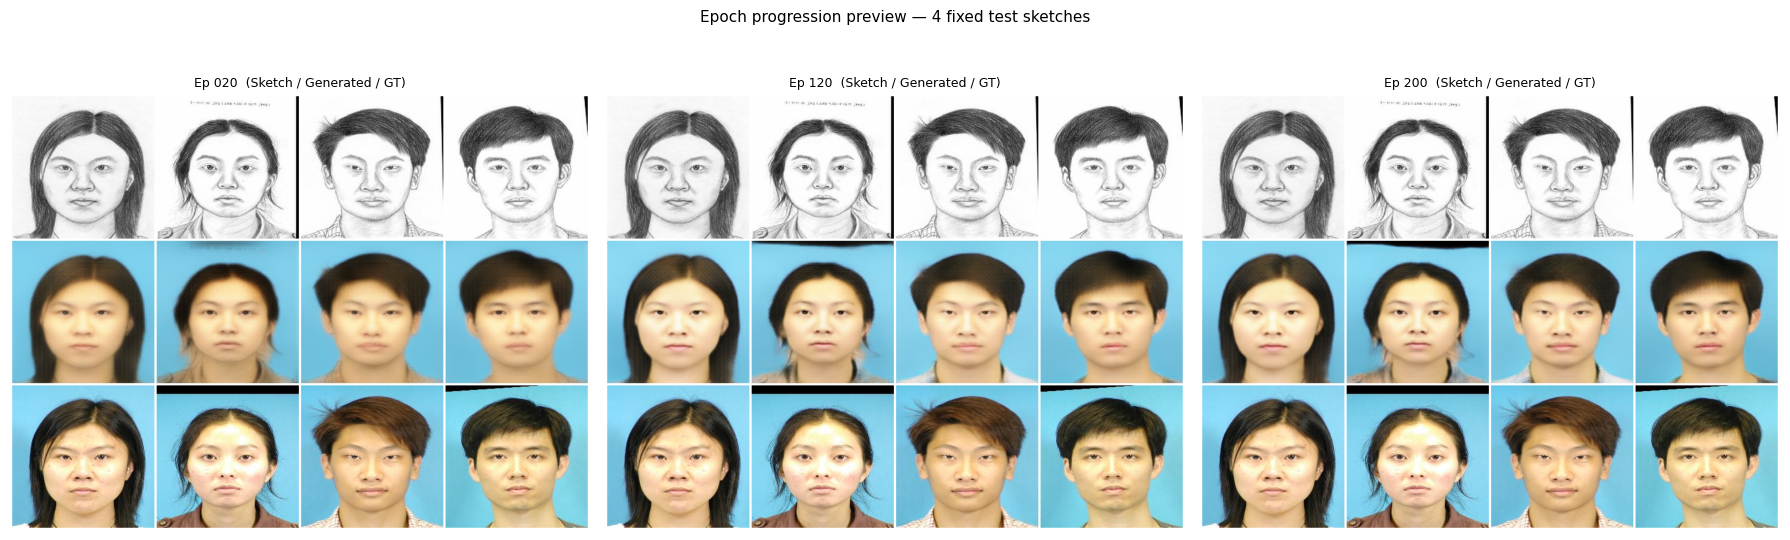

Preview saved: /content/drive/MyDrive/Sketch2Face/results/progression_preview.png


In [ ]:
# ── Visual progression: 4 fixed sketches across all epochs ──────────────────
# Picks 4 random test samples ONCE (fixed seed so results are reproducible).
# For every checkpoint, generates the coarse photo and saves a 3-row grid:
#   Row 1 : Input sketch
#   Row 2 : Generated photo
#   Row 3 : Ground truth photo
# All epochs combined into one tall comparison image at the end.

import random
import torchvision.utils as vutils
import math

random.seed(42)
torch.manual_seed(42)

VISUAL_DIR = os.path.join(RESULTS_DIR, 'epoch_progression')
os.makedirs(VISUAL_DIR, exist_ok=True)

N_SAMPLES = 4   # number of fixed test sketches

# ── Step 1: pick 4 fixed indices from the test dataset ───────────────────────
total_test = len(test_dataset)
fixed_indices = random.sample(range(total_test), min(N_SAMPLES, total_test))
print(f'Fixed test indices: {fixed_indices}')

# Load those 4 samples (sketch + real photo) — done once
fixed_sketches = []
fixed_reals    = []
fixed_paths    = []

for idx in fixed_indices:
    sample = test_dataset[idx]
    fixed_sketches.append(sample['sketch'])   # (3, H, W) float32 [-1,1]
    fixed_reals.append(sample['photo'])        # (3, H, W) float32 [-1,1]
    fixed_paths.append(os.path.basename(sample['sketch_path']))

fixed_sketches = torch.stack(fixed_sketches)   # (4, 3, H, W)
fixed_reals    = torch.stack(fixed_reals)       # (4, 3, H, W)

print(f'Loaded {N_SAMPLES} fixed samples:')
for i, p in enumerate(fixed_paths):
    print(f'  [{i}] {p}')

# ── Step 2: for each checkpoint generate outputs and save per-epoch grid ──────
# Per-epoch grid layout:
#   Column per sample (4 columns)
#   Row 1: sketch | Row 2: generated | Row 3: ground truth

def make_epoch_grid(sketches, fakes, reals, epoch_label):
    """
    Builds a grid image: 3 rows x N_SAMPLES columns.
    sketches, fakes, reals : (N, 3, H, W) float32 [-1, 1]
    Returns a single PIL/numpy image.
    """
    # Shift to [0, 1]
    s01 = (sketches * 0.5 + 0.5).clamp(0, 1)
    f01 = (fakes    * 0.5 + 0.5).clamp(0, 1)
    r01 = (reals    * 0.5 + 0.5).clamp(0, 1)

    n   = s01.size(0)
    H, W = s01.shape[2], s01.shape[3]

    # Stack: sketch row, fake row, real row — interleaved per column
    # Order: s0 s1 s2 s3 | f0 f1 f2 f3 | r0 r1 r2 r3
    all_imgs = torch.cat([s01, f01, r01], dim=0)   # (3N, 3, H, W)

    # make_grid arranges nrow images per row
    grid = vutils.make_grid(all_imgs, nrow=n, padding=4, pad_value=1.0)
    return grid   # (3, grid_H, grid_W)


def add_row_labels(grid_np, row_labels, row_height):
    """
    Adds text labels on the left margin of each row.
    grid_np : (H, W, 3) uint8
    """
    import cv2
    H, W = grid_np.shape[:2]
    margin = 90
    canvas = np.ones((H, W + margin, 3), dtype=np.uint8) * 255
    canvas[:, margin:] = grid_np

    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.42
    thickness  = 1
    color      = (50, 50, 50)

    for i, label in enumerate(row_labels):
        y_center = int((i + 0.5) * row_height)
        (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)
        y_pos = y_center + th // 2
        cv2.putText(canvas, label, (4, y_pos),
                    font, font_scale, color, thickness, cv2.LINE_AA)
    return canvas


epoch_grids  = []   # store (epoch_num, grid_tensor) for combined image
epoch_labels = []

for ckpt_path in sorted(ckpt_paths):
    ckpt_name = os.path.basename(ckpt_path).replace('.pth', '')

    # Parse epoch number
    try:
        ep_num = int(ckpt_name.replace('ckpt_', ''))
    except ValueError:
        ep_num = 9999

    # Load generator
    G_vis = UNetGenerator(in_ch=3, out_ch=3, ngf=64).to(DEVICE)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    G_vis.load_state_dict(ckpt['G'])
    G_vis.eval()

    # Generate outputs for the 4 fixed sketches
    with torch.no_grad():
        fakes = G_vis(fixed_sketches.to(DEVICE)).cpu()

    del G_vis
    torch.cuda.empty_cache()

    # Build grid (3 rows x 4 cols)
    grid = make_epoch_grid(fixed_sketches, fakes, fixed_reals, ckpt_name)
    epoch_grids.append(grid)
    epoch_labels.append(f'Ep {ep_num:03d}')

    # Save individual epoch grid
    grid_np = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    H_row   = grid_np.shape[0] // 3

    labeled = add_row_labels(grid_np,
                             ['Sketch', 'Generated', 'Ground truth'],
                             H_row)

    save_path = os.path.join(VISUAL_DIR, f'{ckpt_name}_progression.png')
    cv2.imwrite(save_path, cv2.cvtColor(labeled, cv2.COLOR_RGB2BGR))
    print(f'  Saved: {os.path.basename(save_path)}')

print(f'\nPer-epoch grids saved to: {VISUAL_DIR}')

# ── Step 3: combined tall image — all epochs stacked vertically ──────────────
# Layout: epoch label on left, then 3-row grid
# Useful for showing full training progression in your paper.

if epoch_grids:
    # All grids same size — stack vertically with separator
    sep_h   = 6   # pixels between epochs
    sep_row = torch.ones(3, sep_h, epoch_grids[0].shape[2])

    combined_rows = []
    for i, (grid, label) in enumerate(zip(epoch_grids, epoch_labels)):
        combined_rows.append(grid)
        if i < len(epoch_grids) - 1:
            combined_rows.append(sep_row)

    combined = torch.cat(combined_rows, dim=1)   # (3, total_H, W)
    combined_np = (combined.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # Add epoch labels on left margin of each epoch block
    grid_h     = epoch_grids[0].shape[1]
    row_h      = grid_h // 3
    margin     = 90
    total_H, total_W = combined_np.shape[:2]
    canvas = np.ones((total_H, total_W + margin, 3), dtype=np.uint8) * 255
    canvas[:, margin:] = combined_np

    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.45
    thickness  = 1
    color      = (30, 30, 30)

    for i, label in enumerate(epoch_labels):
        y_top = i * (grid_h + sep_h)
        # Epoch label at top of each block
        cv2.putText(canvas, label,
                    (4, y_top + 16),
                    font, font_scale, color, thickness, cv2.LINE_AA)
        # Row labels
        for j, row_label in enumerate(['Sk', 'Gen', 'GT']):
            y_center = y_top + int((j + 0.5) * row_h)
            cv2.putText(canvas, row_label,
                        (4, y_center + 5),
                        font, 0.35, (100, 100, 100), 1, cv2.LINE_AA)

    combined_path = os.path.join(RESULTS_DIR, 'full_epoch_progression.png')
    cv2.imwrite(combined_path, cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))
    print(f'Combined progression saved: {combined_path}')

    # ── Show preview in notebook ──────────────────────────────────────────────
    # Display first, middle, and last epoch side by side for quick check
    preview_indices = [0, len(epoch_grids)//2, len(epoch_grids)-1]
    fig, axes = plt.subplots(1, len(preview_indices),
                             figsize=(6 * len(preview_indices), 6))
    if len(preview_indices) == 1:
        axes = [axes]

    for ax, pi in zip(axes, preview_indices):
        g = epoch_grids[pi].permute(1, 2, 0).numpy()
        ax.imshow(g)
        ax.set_title(f'{epoch_labels[pi]}  (Sketch / Generated / GT)',
                     fontsize=9)
        ax.axis('off')

    plt.suptitle('Epoch progression preview — 4 fixed test sketches',
                 fontsize=11)
    plt.tight_layout()
    preview_path = os.path.join(RESULTS_DIR, 'progression_preview.png')
    plt.savefig(preview_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Preview saved: {preview_path}')
